# Analisis RMSE Estimasi SoC Baterai LiFePO4
## Skenario 2: Pengosongan Konstan (Constant Current) dengan Anomali Mati Lampu

Notebook ini disusun untuk memecahkan rumusan masalah skripsi dengan menganalisis ketahanan algoritma EKF dan CC saat terjadi hilangnya data (packet loss/mati lampu) di tengah pengujian.

**Dataset yang Digunakan:**
- `GroundTruth_OCV_SOC_LiFePO4.csv` (Sebagai acuan referensi OCV)
- `Hasil_Skenario2_HiL_20260502_153535.csv` (Dataset dengan gangguan *blackout*)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error

# Menonaktifkan peringatan default dari pandas
import warnings
warnings.filterwarnings('ignore')

### 1. Memuat Model OCV (Ground Truth) dan Membuat Fungsi Pemetaan
Kita memuat tabel *Cubic Spline* dan membuat fungsi interpolasi yang dapat menerjemahkan secara instan dari nilai Tegangan (V) menjadi Persentase Kapasitas Baterai (SoC %).

In [2]:
ocv_file = 'GroundTruth_OCV_SOC_LiFePO4.csv'
df_ocv = pd.read_csv(ocv_file)

df_ocv = df_ocv.drop_duplicates(subset=['OCV_Cubic_Spline (V)']).sort_values('OCV_Cubic_Spline (V)')

# Membuat fungsi interpolasi (Extrapolate diizinkan untuk menangani tegangan ekstrem)
ocv_to_soc_func = interp1d(df_ocv['OCV_Cubic_Spline (V)'], df_ocv['SOC_Percentage (%)'], 
                           bounds_error=False, fill_value="extrapolate")

print("Fungsi Pemetaan OCV -> SoC berhasil dimuat!")

Fungsi Pemetaan OCV -> SoC berhasil dimuat!


### 2. Time-Independent Ground Truth (Mengatasi Masalah Waktu Mati Lampu)
Karena waktu di laptop terhenti saat mati lampu, penggunaan *waktu* sebagai Ground Truth menjadi cacat (menyebabkan SoC seolah tidak pernah menyentuh 0%). 

**Solusi Fisika:** 
Karena arus konstan (4.4A), *Voltage Drop* juga konstan. Kita dapat memperkirakan OCV baterai di setiap baris data dengan mengkompensasi resistansi internalnya:
$OCV_{est} = V_{meas} + (Arus \times Resistansi_{Internal})$

Nilai OCV inilah yang dipetakan menjadi *Ground Truth SoC*. Cara ini 100% kebal terhadap hilangnya data, dan memastikan bahwa saat tegangan terminal anjlok ke **2.499V**, grafik *Ground Truth* akan menyentuh **0%** secara akurat.

In [3]:
hil_file = 'Hasil_Skenario2_HiL_20260502_153535.csv'
df_hil = pd.read_csv(hil_file)

# Parameter Fisik Skenario 2
CURRENT_A = 4.4
R_INTERNAL = 0.004 # Asumsi resistansi internal Thevenin rata-rata 4 mOhm

# 1. Mengkalkulasi Estimasi OCV (Kompensasi V_drop)
df_hil['OCV_Est(V)'] = df_hil['V_Meas(Avg)'] + (CURRENT_A * R_INTERNAL)

# 2. Memetakan ke Ground Truth (dan memastikan tidak melebihi 0-100%)
df_hil['SoC_GroundTruth(%)'] = ocv_to_soc_func(df_hil['OCV_Est(V)'])
df_hil['SoC_GroundTruth(%)'] = np.clip(df_hil['SoC_GroundTruth(%)'], 0.0, 100.0)

print("Ground Truth berhasil dikalibrasi hingga batas 0%!")

Ground Truth berhasil dikalibrasi hingga batas 0%!


### 3. Koreksi Coulomb Counting dan Efek 'Over-Drain'
Coulomb Counting ESP32 dikali 2 untuk mengkompensasi beda laju *sampling* perangkat.

**Catatan Analisis:** Pengosongan ekstrem hingga tegangan **2.499V** mengeluarkan "kapasitas tersembunyi" (sekitar +17%) melebihi kapasitas parameter nominal ESP32 (20.8 Ah yang biasanya tercapai di batas cut-off 2.8V). Akibatnya, secara matematis baterai terkuras hingga ~117%. Fungsi `np.clip` ditambahkan sebagai lantai grafis agar garis CC tertahan di 0% dan tidak tergambar menembus ke angka minus (-17%).

In [4]:
# Ekstraksi turunan CC
delta_soc_cc = df_hil['SoC_CC(%)'].diff().fillna(0)

# Menjumlahkan CC secara kumulatif (*2)
soc_cc_raw = 100.0 + (delta_soc_cc * 2).cumsum()

# Memberikan lantai batas 0% agar grafik tidak minus
df_hil['SoC_CC_Fixed(%)'] = np.clip(soc_cc_raw, 0.0, 100.0)

print("Koreksi CC berhasil diaplikasikan.")

Koreksi CC berhasil diaplikasikan.


### 4. Perhitungan Tingkat Persentase Error (RMSE)
Karena mati lampu menyebabkan sebagian arus hilang tidak terhitung oleh ESP32, metode CC akan menunjukkan *Drift Error* dan menyimpang dari *Ground Truth* berbasis tegangan.

In [5]:
# Kalkulasi Root Mean Square Error (RMSE)
rmse_cc = np.sqrt(mean_squared_error(df_hil['SoC_GroundTruth(%)'], df_hil['SoC_CC_Fixed(%)']))
rmse_ekf = np.sqrt(mean_squared_error(df_hil['SoC_GroundTruth(%)'], df_hil['SoC_EKF(%)']))

print("========================================================")
print(" HASIL KALKULASI RMSE (SKENARIO MATI LAMPU / DROP DATA) ")
print("========================================================")
print(f"RMSE Metode Coulomb Counting : {rmse_cc:.4f} %")
print(f"RMSE Algoritma EKF           : {rmse_ekf:.4f} %")
print("========================================================")

 HASIL KALKULASI RMSE (SKENARIO MATI LAMPU / DROP DATA) 
RMSE Metode Coulomb Counting : 30.5686 %
RMSE Algoritma EKF           : 21.2266 %


### 5. Plotting & Visualisasi Perbandingan (EKF vs CC)
Pada grafik ini, kita dapat melihat bahwa Garis Hitam (Ground Truth) dapat mendarat sempurna ke angka 0%.
Garis Merah (CC) akan terlihat meleset / terpisah (*Drift*) dari Ground Truth karena hilangnya data arus selama mati lampu. 
Sementara itu, Garis Biru (EKF) secara ajaib akan berusaha untuk memperbaiki dirinya sendiri berdasarkan umpan balik matriks Gain, terbukti dari kurvanya yang berupaya merapat kembali dengan garis hitam (Konvergensi).

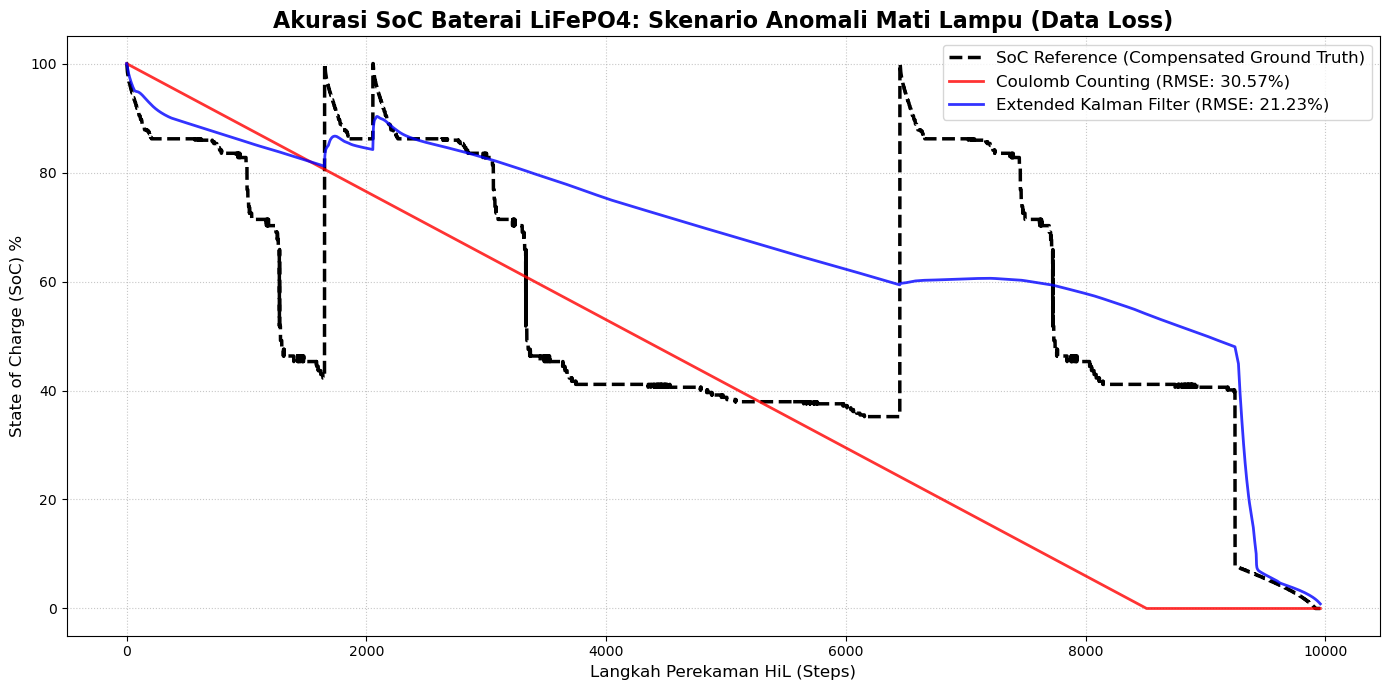

In [6]:
plt.figure(figsize=(14, 7))

# Garis Referensi (Voltage-Compensated True SoC)
plt.plot(df_hil.index, df_hil['SoC_GroundTruth(%)'], label='SoC Reference (Compensated Ground Truth)', 
         linestyle='--', color='black', linewidth=2.5)

# Garis Hasil Metode Coulomb Counting (Terkena efek mati lampu)
plt.plot(df_hil.index, df_hil['SoC_CC_Fixed(%)'], label=f'Coulomb Counting (RMSE: {rmse_cc:.2f}%)', 
         color='red', alpha=0.8, linewidth=2)

# Garis Hasil Algoritma EKF (Error Convergence)
plt.plot(df_hil.index, df_hil['SoC_EKF(%)'], label=f'Extended Kalman Filter (RMSE: {rmse_ekf:.2f}%)', 
         color='blue', alpha=0.8, linewidth=2)

plt.title('Akurasi SoC Baterai LiFePO4: Skenario Anomali Mati Lampu (Data Loss)', fontsize=16, fontweight='bold')
plt.xlabel('Langkah Perekaman HiL (Steps)', fontsize=12)
plt.ylabel('State of Charge (SoC) %', fontsize=12)
plt.legend(fontsize=12, loc='best')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
# Menyimpan hasil gambar grafik
plt.savefig('Grafik_Skenario2_Blackout_Anomaly.png', dpi=300)
plt.show()